/var/folders/65/1g3d5l0s4c1dmhh4lc5np1lm0000gn/T/ipykernel_12273/1859277688.py:363: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(aviones))


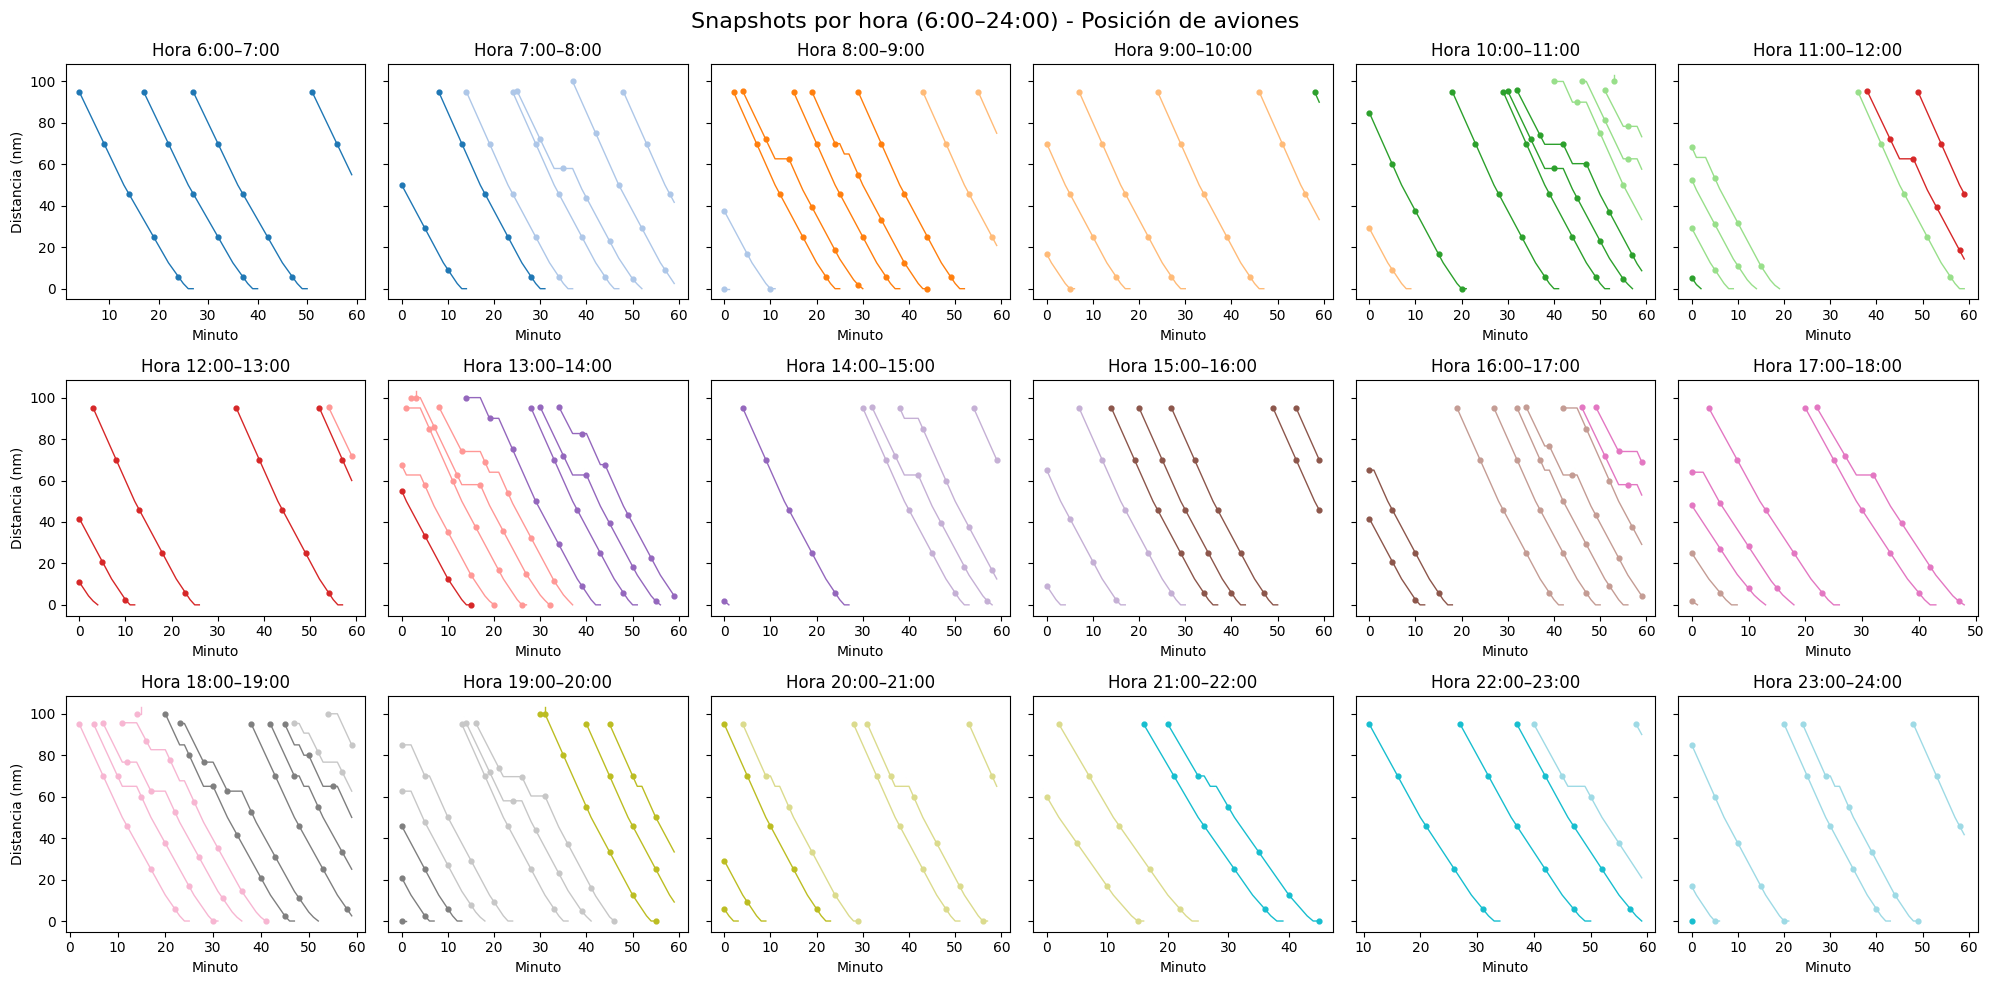

Tiempos de aterrizaje: [27, 40, 50, 74, 91, 97, 107, 112, 121, 131, 145, 150, 158, 164, 172, 186, 198, 210, 227, 249, 261, 281, 292, 297, 302, 309, 314, 319, 359, 364, 372, 386, 417, 435, 440, 447, 452, 457, 463, 471, 476, 481, 507, 533, 538, 544, 557, 570, 577, 583, 590, 612, 618, 642, 650, 656, 661, 668, 673, 678, 686, 703, 708, 745, 751, 756, 761, 767, 772, 781, 787, 793, 798, 804, 816, 821, 826, 835, 843, 849, 863, 869, 891, 897, 916, 925, 939, 945, 994, 1010, 1020, 1026, 1041, 1063, 1069]
Separaciones entre aterrizajes: [13, 10, 24, 17, 6, 10, 5, 9, 10, 14, 5, 8, 6, 8, 14, 12, 12, 17, 22, 12, 20, 11, 5, 5, 7, 5, 5, 40, 5, 8, 14, 31, 18, 5, 7, 5, 5, 6, 8, 5, 5, 26, 26, 5, 6, 13, 13, 7, 6, 7, 22, 6, 24, 8, 6, 5, 7, 5, 5, 8, 17, 5, 37, 6, 5, 5, 6, 5, 9, 6, 6, 5, 6, 12, 5, 5, 9, 8, 6, 14, 6, 22, 6, 19, 9, 14, 6, 49, 16, 10, 6, 15, 22, 6]
✅ Todas las separaciones cumplen el mínimo de 4 minutos
⚠️ 39 estuvo a -9.00 min del avión 38 en t=423
⚠️ 82 estuvo a -9.00 min del avión 81 en t=811

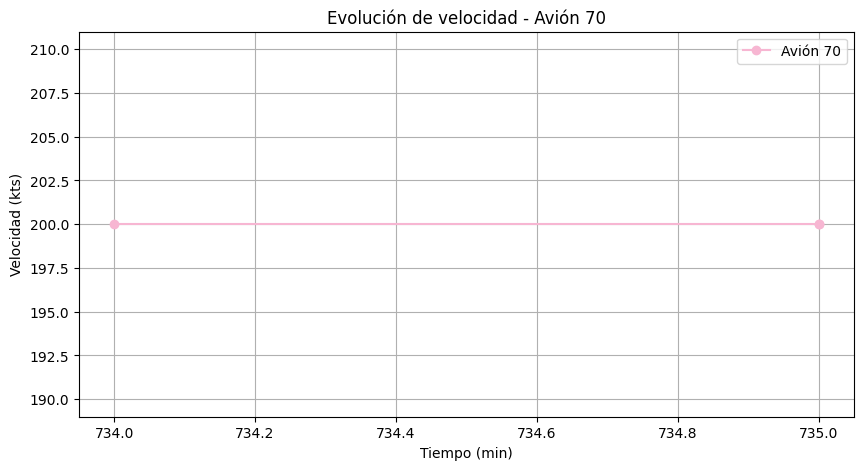

--- Debug de trayectoria: Avión 1 ---
t=   4 min | distancia= 95.00 nm | vel=300.00 kts | estado=acercandose
t=   5 min | distancia= 90.00 nm | vel=300.00 kts | estado=acercandose
t=   6 min | distancia= 85.00 nm | vel=300.00 kts | estado=acercandose
t=   7 min | distancia= 80.00 nm | vel=300.00 kts | estado=acercandose
t=   8 min | distancia= 75.00 nm | vel=300.00 kts | estado=acercandose
t=   9 min | distancia= 70.00 nm | vel=300.00 kts | estado=acercandose
t=  10 min | distancia= 65.00 nm | vel=300.00 kts | estado=acercandose
t=  11 min | distancia= 60.00 nm | vel=300.00 kts | estado=acercandose
t=  12 min | distancia= 55.00 nm | vel=300.00 kts | estado=acercandose
t=  13 min | distancia= 50.00 nm | vel=300.00 kts | estado=acercandose
t=  14 min | distancia= 45.83 nm | vel=250.00 kts | estado=acercandose
t=  15 min | distancia= 41.67 nm | vel=250.00 kts | estado=acercandose
t=  16 min | distancia= 37.50 nm | vel=250.00 kts | estado=acercandose
t=  17 min | distancia= 33.33 nm | vel=

In [184]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from dataclasses import dataclass, field
from typing import List, Tuple, Optional, Dict

# =========================
# Configuración reproducible
# =========================
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# =========================
# Parámetros del problema
# =========================
MIN_ESPACIO = 4.0           # separación mínima en minutos
ESPACIO_OBJETIVO = 5.0      # separación objetivo (usado en incisos posteriores)
RADAR_NM = 100.0            # distancia a la que entran en radar (mn)
VELOCIDAD_DE_RETROCESO_KTS = 200.0
NUDOS_A_MNxMIN = 1.0 / 60.0  # conversión nudos -> mn/min


def rango_de_velocidad_permitido(distancia_a_mn: float) -> Tuple[float, float]:
    """Devuelve (min_kts, max_kts) permitidos según la tabla del enunciado."""
    if distancia_a_mn > 100.0:
        return 300.0, 500.0
    elif distancia_a_mn > 50.0:
        return 250.0, 300.0   # 100..50
    elif distancia_a_mn > 15.0:
        return 200.0, 250.0   # 50..15
    elif distancia_a_mn > 5.0:
        return 150.0, 200.0   # 15..5
    else:
        return 120.0, 150.0   # 5..0
    
def manejar_en_fila(avion, adelante, t):
    """Gestiona un avión cuando está en fila (acercándose)"""
    # calcular gap
    eta_self = avion.distancia_a_mn / (avion.velocidad_kts * NUDOS_A_MNxMIN)
    eta_front = adelante.distancia_a_mn / (adelante.velocidad_kts * NUDOS_A_MNxMIN)
    gap = eta_self - eta_front

    if gap < 4:  # demasiado cerca
        nueva_vel = adelante.velocidad_kts - 20
        vmin, _ = rango_de_velocidad_permitido(avion.distancia_a_mn)

        if nueva_vel < vmin:
            avion.estado = "retrocediendo"
            avion.velocidad_kts = 200
        else:
            avion.velocidad_kts = nueva_vel

    elif gap >= 5:  # vuelve a velocidad máxima
        _, vmax = rango_de_velocidad_permitido(avion.distancia_a_mn)
        avion.velocidad_kts = vmax

def manejar_retrocediendo(avion, aviones_en_vuelo, t):
    """Gestiona un avión que está retrocediendo"""
    # check de desvío
    if avion.distancia_a_mn > 100:
        avion.estado = "desviado"
        
        return

    # buscar gaps en ETAs
    etas = sorted([
        otro.distancia_a_mn / (otro.velocidad_kts * NUDOS_A_MNxMIN)
        for otro in aviones_en_vuelo if otro != avion and otro.estado != "retrocediendo"
    ])

    for i in range(len(etas)-1):
        gap = etas[i+1] - etas[i]
        if gap >= 10:
            _, vmax = rango_de_velocidad_permitido(avion.distancia_a_mn)
            avion.estado = "acercandose"
            avion.velocidad_kts = vmax
            
            return


    
    
def puede_reinsertarse(avion, aviones_en_vuelo, t, min_gap=10.0):
    """
    Devuelve True si el avión retrocediendo puede reinsertarse en la fila
    porque encuentra un gap >= min_gap minutos entre dos ETAs consecutivos.
    """
    # Calcular ETA del retrocediendo si volviera a velocidad máxima
    _, vmax = rango_de_velocidad_permitido(avion.distancia_a_mn)
    eta_self = t + avion.distancia_a_mn / (vmax * NUDOS_A_MNxMIN)

    # ETAs de los demás aviones en acercándose
    etas = []
    for otro in aviones_en_vuelo:
        if otro == avion or otro.estado != "acercandose":
            continue
        if otro.velocidad_kts > 0:
            eta_otro = t + otro.distancia_a_mn / (otro.velocidad_kts * NUDOS_A_MNxMIN)
            etas.append(eta_otro)

    etas.sort()

    # Buscar huecos consecutivos
    for i in range(len(etas) - 1):
        if etas[i] <= eta_self <= etas[i+1] and (etas[i+1] - etas[i]) >= min_gap:
            return True

    # También puede entrar después del último
    if etas and eta_self > etas[-1] and (1080 - etas[-1]) >= min_gap:
        return True

    # Si no hay nadie en vuelo, puede entrar
    if not etas:
        return True

    return False


















# =========================
# Clase Avion
# =========================
@dataclass
class Avion:
    avion_id: int
    tiempo_de_aparicion: int
    distancia_a_mn: float = RADAR_NM
    velocidad_kts: float = 0.0
    estado: str = "acercandose"  # acercandose | retrocediendo | desviado | aterrizado
    tiempo_de_aterrizaje: Optional[int] = None
    tiempo_de_desvio: Optional[int] = None
    historial_de_tiempos: List[int] = field(default_factory=list)
    historial_de_distancias: List[float] = field(default_factory=list)
    historial_de_velocidades: List[float] = field(default_factory=list)
    historial_de_estados: List[str] = field(default_factory=list)
    congestionado: bool = False
    tiempo_sin_congestion: Optional[int] = None
    atraso: Optional[float] = None


    def tiempo_estimado_de_llegada(self):
        if self.velocidad_kts > 0 and self.estado in ["acercandose", "retrocediendo"]:
            return self.distancia_a_mn / (self.velocidad_kts * NUDOS_A_MNxMIN)
        return None


    def eta_si_vuelvo(self):
        """Tiempo estimado a pista si retoma vuelo normal a velocidad máxima."""
        if self.estado == "retrocediendo":
            _, vmax = rango_de_velocidad_permitido(self.distancia_a_mn)
            return self.distancia_a_mn / (vmax * NUDOS_A_MNxMIN)
        else:
            return self.tiempo_estimado_de_llegada()
    


    def registrar(self, t: int):
        """Guarda el tiempo y distancia actual en la trayectoria."""
        self.historial_de_tiempos.append(t)
        self.historial_de_distancias.append(self.distancia_a_mn)
        self.historial_de_velocidades.append(self.velocidad_kts)
        self.historial_de_estados.append(self.estado)

    


    # Compatibilidad con graficar_snapshots
    @property
    def trayectoria(self) -> List[Tuple[int, float]]:
        return list(zip(self.historial_de_tiempos, self.historial_de_distancias))

    @property
    def id(self):
        return self.avion_id






# =========================
# Clase Aeropuerto AEP
# =========================
class AEP:
    """Simulación de arribos y aproximación a AEP (inciso 1 con separación mínima)."""
    def __init__(self, lam: float, T_minutes: int):
        assert 0.0 < lam <= 1.0, "λ debe estar entre 0 y 1"
        self.lam = lam
        self.T = T_minutes
        self.aviones: List[Avion] = []
        self.next_id = 1
        self.ultimo_aterrizaje = -1  # -1 significa que todavía no aterrizó nadie

    def generar_si_llega(self, t: int):
        """Genera un nuevo avión en el radar si ocurre un arribo en este minuto."""
        if rng.random() < self.lam:
            _, max_kts = rango_de_velocidad_permitido(RADAR_NM)
            avion = Avion(
                avion_id=self.next_id,
                tiempo_de_aparicion=t,
                distancia_a_mn=RADAR_NM,
                velocidad_kts=max_kts,
                estado="acercandose"
            )
            self.aviones.append(avion)
            self.next_id += 1

    def actualizacion_de_posicion(self, t: int):
        """Avanza todos los aviones aplicando separación mínima de 4 min en vuelo y pista."""

        # ordenar por distancia a la pista (más cerca primero)
        aviones_en_vuelo = [a for a in self.aviones if a.estado == "acercandose"]
        aviones_en_vuelo.sort(key=lambda a: a.distancia_a_mn)

        for i, avion in enumerate(aviones_en_vuelo):
            vmin, vmax = rango_de_velocidad_permitido(avion.distancia_a_mn)
            velocidad = vmax  # por defecto máxima

            if i > 0:  # hay un avión adelante
                avion_adelante = aviones_en_vuelo[i-1]

                # tiempos estimados a pista (minutos)
                tiempo_adelante = (avion_adelante.distancia_a_mn /
                                (avion_adelante.velocidad_kts * NUDOS_A_MNxMIN)) if avion_adelante.velocidad_kts > 0 else float("inf")
                tiempo_actual = (avion.distancia_a_mn /
                                (vmax * NUDOS_A_MNxMIN)) if vmax > 0 else float("inf")

                separacion = tiempo_actual - tiempo_adelante

                if separacion < MIN_ESPACIO:
                    # ahora se ajusta a la velocidad del avión de adelante - 20
                    velocidad = avion_adelante.velocidad_kts - 20

                    if velocidad < vmin:
                        # 🚨 no puede → retrocede
                        avion.estado = "retrocediendo"
                        avion.velocidad_kts = VELOCIDAD_DE_RETROCESO_KTS
                        
                        avion.congestionado = True
                        avion.registrar(t)
                        continue

                # congestión: si va más lento que su vmax
                if velocidad < vmax:
                    avion.congestionado = True

            # avanzar normal (solo si está en acercandose)
            avion.velocidad_kts = velocidad
            avion.distancia_a_mn -= avion.velocidad_kts * NUDOS_A_MNxMIN

            # aterrizaje
            if avion.distancia_a_mn <= 0:
                llegada = t
                if self.ultimo_aterrizaje < 0:
                    aterrizaje_real = llegada
                else:
                    aterrizaje_real = max(llegada, self.ultimo_aterrizaje + MIN_ESPACIO)

                avion.distancia_a_mn = 0
                avion.estado = "aterrizado"
                avion.tiempo_de_aterrizaje = aterrizaje_real
                self.ultimo_aterrizaje = aterrizaje_real

                # 🔹 Calcular atraso comparando con el vuelo ideal
                _, vmax_ini = rango_de_velocidad_permitido(RADAR_NM)
                tiempo_ideal = avion.tiempo_de_aparicion + RADAR_NM / (vmax_ini * NUDOS_A_MNxMIN)
                avion.tiempo_sin_congestion = tiempo_ideal
                avion.atraso = aterrizaje_real - tiempo_ideal

            avion.registrar(t)

        # 🔄 Chequear reinserción de retrocediendo
        retrocediendo = [a for a in self.aviones if a.estado == "retrocediendo"]
        for avion in retrocediendo:
            if avion.distancia_a_mn > RADAR_NM:
                avion.estado = "desviado"
                avion.tiempo_de_desvio = t
                
            else:
                if puede_reinsertarse(avion, self.aviones, t, min_gap=10.0):
                    avion.estado = "acercandose"
                    _, vmax = rango_de_velocidad_permitido(avion.distancia_a_mn)
                    avion.velocidad_kts = vmax
                    
                else:
                    # sigue retrocediendo
                    avion.distancia_a_mn += avion.velocidad_kts * NUDOS_A_MNxMIN
                    avion.registrar(t)




















    def run(self) -> Dict[str, int]:
        """Corre la simulación completa de T minutos."""
        for t in range(self.T):
            self.generar_si_llega(t)
            self.actualizacion_de_posicion(t)
        return {
            "aparecieron": len(self.aviones),
            "aterrizado": sum(1 for a in self.aviones if a.estado == "aterrizado"),
            "sigue_acercandose": sum(1 for a in self.aviones if a.estado == "acercandose"),
            "retrocediendo": sum(1 for a in self.aviones if a.estado == "retrocediendo"),
        }


# =========================
# Simulación 
# =========================
def simular_trayectorias(lambda_hora=0.017, duracion_horas=18, seed=42):
    rng = np.random.default_rng(seed)
    total_min = int(duracion_horas * 60)
    sim = AEP(lam=lambda_hora, T_minutes=total_min)
    sim.run()
    return sim.aviones

# =========================
# Funcion auxiliar para incisos 3
# =========================

def simular_dia(lam: float, minutos: int = 60) -> int:
    """Simula 1 hora de arribos (minuto a minuto) y devuelve cuántos aviones llegaron."""
    arribos = 0
    for _ in range(minutos):
        if rng.random() < lam:
            arribos += 1
    return arribos

# =========================
# Graficado 
# =========================
def graficar_snapshots(aviones, duracion_horas=18):
    cmap = cm.get_cmap("tab20", len(aviones))
    colores = {avion.id: cmap(i) for i, avion in enumerate(aviones)}

    fig, axes = plt.subplots(3, 6, figsize=(20, 10), sharey=True)
    axes = axes.flatten()

    for h in range(duracion_horas):
        minuto_ini = h * 60
        minuto_fin = (h + 1) * 60
        ax = axes[h]

        for avion in aviones:
            ts, ds = [], []
            limite = avion.tiempo_de_aterrizaje if avion.tiempo_de_aterrizaje is not None else minuto_fin
            for t, d in avion.trayectoria:
                if minuto_ini <= t < minuto_fin and t <= limite:
                    ts.append(t - minuto_ini)
                    ds.append(d)

            if ts:
                color = colores[avion.id]
                # línea continua
                ax.plot(ts, ds, color=color, linewidth=1)
                # puntos cada 5 muestras
                ax.scatter(ts[::5], ds[::5], c=[color], s=12)

        ax.invert_yaxis()
        ax.set_title(f"Hora {6+h}:00–{7+h}:00")
        ax.set_xlabel("Minuto")
        if h % 6 == 0:
            ax.set_ylabel("Distancia (nm)")

    plt.suptitle("Snapshots por hora (6:00–24:00) - Posición de aviones", fontsize=16)
    plt.tight_layout()
    plt.show()

    return colores


# =========================
# Verificación de separaciones
# =========================
def verificar_separaciones(aviones, min_sep=4):
    """Chequea las separaciones entre aterrizajes y reporta si alguna es < min_sep."""
    aterrizajes = sorted(
        [a.tiempo_de_aterrizaje for a in aviones if a.tiempo_de_aterrizaje is not None]
    )
    diffs = [aterrizajes[i] - aterrizajes[i-1] for i in range(1, len(aterrizajes))]

    print("Tiempos de aterrizaje:", aterrizajes)
    print("Separaciones entre aterrizajes:", diffs)

    violaciones = [(aterrizajes[i-1], aterrizajes[i], diffs[i-1])
                   for i in range(1, len(aterrizajes)) if diffs[i-1] < min_sep]

    if violaciones:
        print(f"⚠️ Se encontraron {len(violaciones)} violaciones (< {min_sep} min):")
        for t1, t2, d in violaciones:
            print(f"- Aterrizajes en {t1} y {t2} (solo {d} minutos de diferencia)")
    else:
        print(f"✅ Todas las separaciones cumplen el mínimo de {min_sep} minutos")


def verificar_separacion_en_vuelo(aviones):
    """Chequea minuto a minuto que se cumpla la lógica de separación en vuelo."""
    aviones_en_vuelo = [a for a in aviones if len(a.trayectoria) > 0]

    for i in range(1, len(aviones_en_vuelo)):
        avion = aviones_en_vuelo[i]
        avion_adelante = aviones_en_vuelo[i-1]

        # recorrer minuto a minuto la trayectoria
        for (t1, d1), (t2, d2) in zip(avion.trayectoria, avion_adelante.trayectoria):
            if t1 != t2:
                continue  # sincronizamos tiempos
            # tiempos estimados a pista
            if avion.velocidad_kts > 0:
                tiempo_restante = d1 / (avion.velocidad_kts * NUDOS_A_MNxMIN)
            else:
                tiempo_restante = float("inf")

            if avion_adelante.velocidad_kts > 0:
                tiempo_restante_adelante = d2 / (avion_adelante.velocidad_kts * NUDOS_A_MNxMIN)
            else:
                tiempo_restante_adelante = float("inf")

            separacion = tiempo_restante - tiempo_restante_adelante

            if separacion < MIN_ESPACIO:
                print(f"⚠️ {avion.id} estuvo a {separacion:.2f} min del avión {avion_adelante.id} en t={t1}")
            elif separacion < (MIN_ESPACIO + 1):
                print(f"ℹ️ {avion.id} está en buffer de seguridad (sep={separacion:.2f} min) en t={t1}")

def mostrar_velocidades(aviones, avion_id: int, colores=None):
    """Grafica la velocidad de un avión a lo largo del tiempo usando el color de snapshots."""
    avion = next((a for a in aviones if a.avion_id == avion_id), None)
    if not avion:
        print(f"No se encontró el avión con id {avion_id}")
        return
    
    color = colores[avion_id] if colores and avion_id in colores else "blue"
    
    plt.figure(figsize=(10, 5))
    plt.plot(avion.historial_de_tiempos, avion.historial_de_velocidades, 
             marker="o", color=color, label=f"Avión {avion_id}")
    plt.title(f"Evolución de velocidad - Avión {avion_id}")
    plt.xlabel("Tiempo (min)")
    plt.ylabel("Velocidad (kts)")
    plt.legend()
    plt.grid(True)
    plt.show()

def debug_trayectoria(aviones, avion_id):
    avion = next((a for a in aviones if a.id == avion_id), None)
    if avion is None:
        print(f"No se encontró el avión {avion_id}")
        return
    
    print(f"--- Debug de trayectoria: Avión {avion.id} ---")
    for t, d, v, e in zip(avion.historial_de_tiempos,
                          avion.historial_de_distancias,
                          avion.historial_de_velocidades,
                          avion.historial_de_estados):
        print(f"t={t:4d} min | distancia={d:6.2f} nm | vel={v:6.2f} kts | estado={e}")








# =========================
# Ejemplo de uso
# =========================
if __name__ == "__main__":
    aviones = simular_trayectorias(lambda_hora=0.1, duracion_horas=18)
    colores=graficar_snapshots(aviones, duracion_horas=18)
    verificar_separaciones(aviones, min_sep=4)  #en pista
    verificar_separacion_en_vuelo(aviones)               # en vuelo
    mostrar_velocidades(aviones, avion_id=70, colores = colores)  
    debug_trayectoria(aviones, 1)   
    debug_trayectoria(aviones, 2)  
    debug_trayectoria(aviones, 4)  
    debug_trayectoria(aviones, 5)  
    debug_trayectoria(aviones, 6)  
    debug_trayectoria(aviones, 7)
    debug_trayectoria(aviones, 8)
    debug_trayectoria(aviones, 9)
    debug_trayectoria(aviones, 10)
    debug_trayectoria(aviones, 11)
    debug_trayectoria(aviones, 12)
    debug_trayectoria(aviones, 13)
    debug_trayectoria(aviones, 14)
    debug_trayectoria(aviones, 15)
    debug_trayectoria(aviones, 29)
    
    



2) Si el promedio de arribos es de 1 avión por hora, cuánto es λ?

In [185]:

promedio_deseado = 1   # 1 avión por hora
n_min = 60             # minutos en una hora

lam = promedio_deseado / n_min

print(f"Si el promedio es {promedio_deseado} avión/hora:")
print(f"λ = {lam:.6f} (probabilidad de arribo por minuto)")


Si el promedio es 1 avión/hora:
λ = 0.016667 (probabilidad de arribo por minuto)


3.Bajo este valor de λ (1/60) y en base a una simulación suficientemente larga, estimá la probabilidad de que lleguen 5 aviones en una hora. Podés verificar tu resultado de manera analítica.

In [186]:
from math import comb, sqrt

# -------------------------
# Parámetros
# -------------------------
lam = 1/60          # prob. de arribo por minuto
n_min = 60          # 1 hora
reps = 200_000      # cantidad de horas simuladas

# -------------------------
# Simulación Monte Carlo (usando simular_dia)
# -------------------------
resultados = [simular_dia(lam, minutos=n_min) for _ in range(reps)]
hits = sum(1 for r in resultados if r == 5)
p_hat = hits / reps

# Error estándar e IC95%
se = sqrt(p_hat * (1 - p_hat) / reps)
ci95 = (p_hat - 1.96*se, p_hat + 1.96*se)

print("===== Inciso 3 =====")
print(f"Simulaciones: {reps:,}")
print(f"Veces con 5 arribos: {hits:,}")
print(f"Estimación Monte Carlo P(N=5): {p_hat:.6f}")
print(f"SE: {se:.6f}  IC95%: ({ci95[0]:.6f}, {ci95[1]:.6f})")

# -------------------------
# Comparación analítica
# -------------------------
p_exact = comb(n_min, 5) * (lam**5) * ((1-lam)**(n_min-5))
print(f"Probabilidad exacta (Binomial): {p_exact:.6f}")


===== Inciso 3 =====
Simulaciones: 200,000
Veces con 5 arribos: 536
Estimación Monte Carlo P(N=5): 0.002680
SE: 0.000116  IC95%: (0.002453, 0.002907)
Probabilidad exacta (Binomial): 0.002787


4) Simul ́a el sistema de arribos con λ ∈ {0.02,0.1,0.2,0.5y1}? Decimos que hay
congesti ́on si un avi ́on debe volar m ́as lento que su velocidad m ́axima posible. El
aumento de λ incrementa la frecuencia de congestiones? Se ven gr ́aficamente? Cu ́al
es el atraso promedio de aviones vs lo que suceder ́ıa sin congesti ́on? Cu ́an frecuente
es un desv ́ıo a Montevideo? Respond ́e en base a un n ́umero de simulaciones suficien-
temente grande y acompa ̃nando cada respuesta num ́erica con su error de estimaci ́on.
Cada tanto sucede un episodio como este
https://www.youtube.com/watch?v=Z7JKt0jwuXc
o sea una interrupci ́on, en cuyo caso el avi ́on desv ́ıa al r ́ıo, cambia el rumbo de manera
instant ́anea en 180 grados y comienza a volar en paralelo y en direcci ́on opuesta a
la cola de aviones en el aire a 200 nudos hasta encontrar el primer hueco en la cola
con un gap de al menos 10 minutos y que est ́e a mas de 5 mn de AEP.

In [ ]:
def simular_experimento(lam, horas=18, reps=50):
    """Corre reps simulaciones y devuelve métricas con IC95%."""
    congestionados, atrasos, desviados = [], [], []
    
    for _ in range(reps):
        sim = AEP(lam=lam, T_minutes=horas*60)
        sim.run()
        for avion in sim.aviones:
            if avion.estado in ["aterrizado", "desviado"]:
                # congestión
                congestionados.append(avion.congestionado)
                # atraso
                if avion.tiempo_de_aterrizaje and avion.tiempo_sin_congestion:
                    atrasos.append(avion.tiempo_de_aterrizaje - avion.tiempo_sin_congestion)
                # desvíos
                desviados.append(avion.estado == "desviado")
    
    def resumen(arr):
        arr = np.array(arr, dtype=float)
        media = arr.mean()
        se = arr.std(ddof=1)/np.sqrt(len(arr))
        return media, (media-1.96*se, media+1.96*se)
    
    p_cong, ic_cong = resumen(congestionados)
    atraso_mean, ic_atraso = resumen(atrasos)
    p_desv, ic_desv = resumen(desviados)
    
    return {
        "lambda": lam,
        "p_congestion": (p_cong, ic_cong),
        "atraso_prom": (atraso_mean, ic_atraso),
        "p_desvio": (p_desv, ic_desv)
    }


lambdas = [0.02, 0.1, 0.2, 0.5, 1]
resultados = [simular_experimento(lam) for lam in lambdas]

for r in resultados:
    print(f"λ={r['lambda']}")
    print(f"Congestión: {r['p_congestion'][0]:.3f}  IC95%={r['p_congestion'][1]}")
    print(f"Atraso prom.: {r['atraso_prom'][0]:.3f} min  IC95%={r['atraso_prom'][1]}")
    print(f"Desvíos: {r['p_desvio'][0]:.3f}  IC95%={r['p_desvio'][1]}")
    print("----")
